Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10148 entries, 0 to 10147
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              10148 non-null  object 
 1   year                                 10148 non-null  int64  
 2   construction                         10148 non-null  int64  
 3   manufacturing                        10148 non-null  float64
 4   mining_manufacturing_utilities       10148 non-null  int64  
 5   transport_storage_and_communication  10148 non-null  float64
 6   other_activities                     10148 non-null  int64  
 7   exports_of_goods_and_services        10148 non-null  float64
 8   imports_of_goods_and_services        10148 non-null  float64
 9   final_consumption_expenditure  

/tmp/ipykernel_15826/3938798124.py:14: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


,manufacturing,mining_manufacturing_utilities,transport_storage_and_communication,other_activities,exports_of_goods_and_services,imports_of_goods_and_services,final_consumption_expenditure,gross_national_income(gni)_in_usd,population,gross_domestic_product_(gdp)
count,10148,10148,10148,10148,10148,10148,10148,10148,10148,10148
mean,11738378598,17908929405,5858899048,25691554204,27364654916,25963076844,54362285571,73113637030,20169198,74497367629
std,34992364869,49553306406,16207689598,82464561375,80378947564,74437715689,159475041108,213862119936,77922039,217369228331
min,-248499,-2581190,-6479048,1044040,-1669759280,1982159,2043926,3564833,4359,2585174
25%,102615718,167418738,85013855,331272109,377887044,554934941,1137124668,1312278666,579323,1330181282
50%,824127566,1424881842,498096937,1913553779,2158413718,2635613804,5841687002,6941895103,4662172,7111072418
75%,5924874065,10204876106,3178551688,11263747345,12543754856,12890490956,30424479161,40453646081,14541965,41499310048
max,461000000000,596000000000,181000000000,1040000000000,840000000000,765000000000,2260000000000,3150000000000,1407563842,3200000000000


Коэффицициет вариации:



,0
manufacturing,298.102200
mining_manufacturing_utilities,276.696084
transport_storage_and_communication,276.633707
other_activities,320.979263
exports_of_goods_and_services,293.732729
imports_of_goods_and_services,286.706064
final_consumption_expenditure,293.356027
gross_national_income(gni)_in_usd,292.506472
population,386.341777
gross_domestic_product_(gdp),291.781086


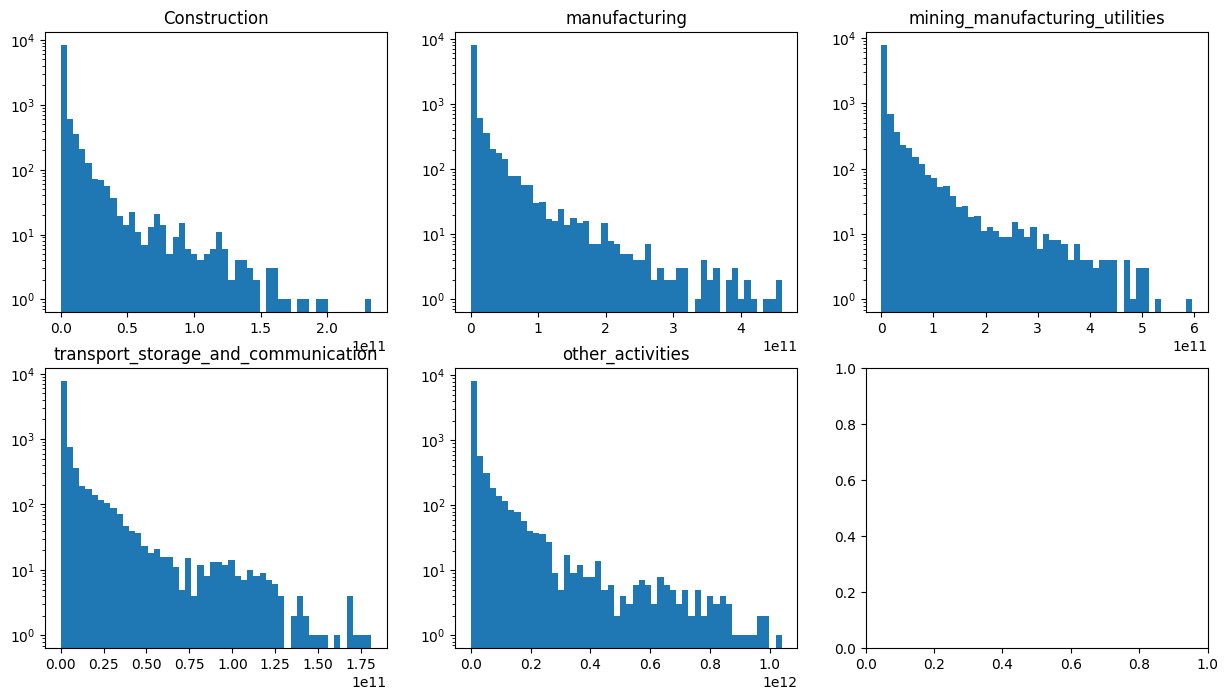

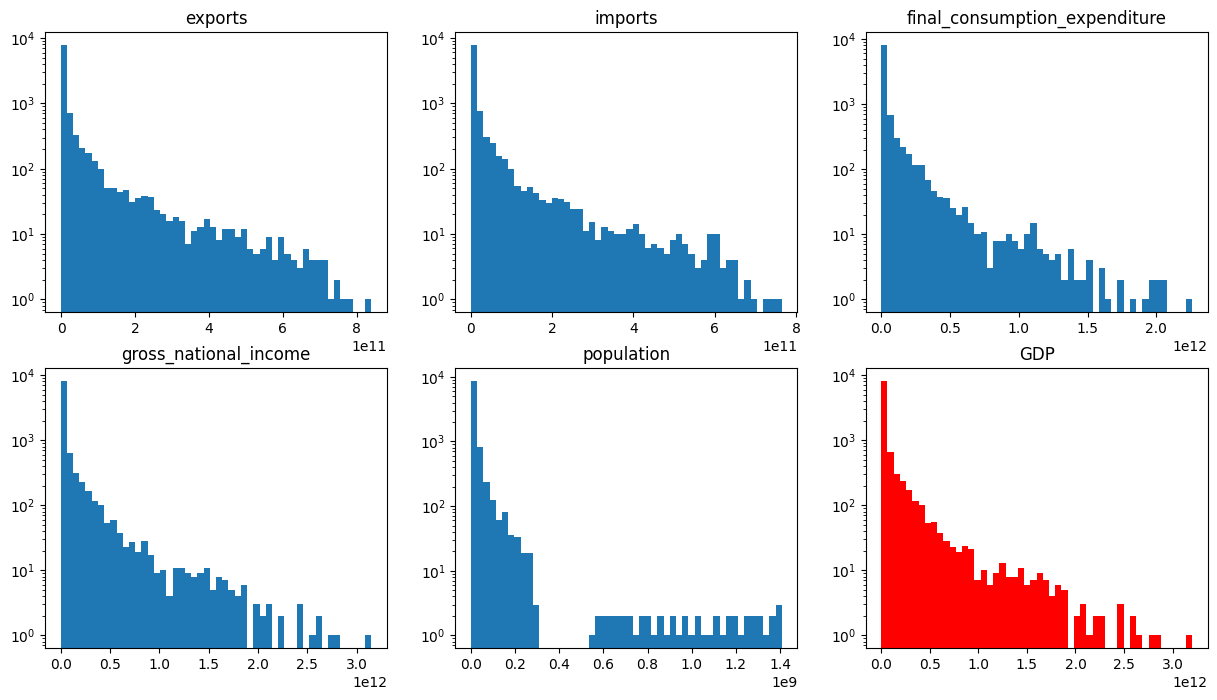

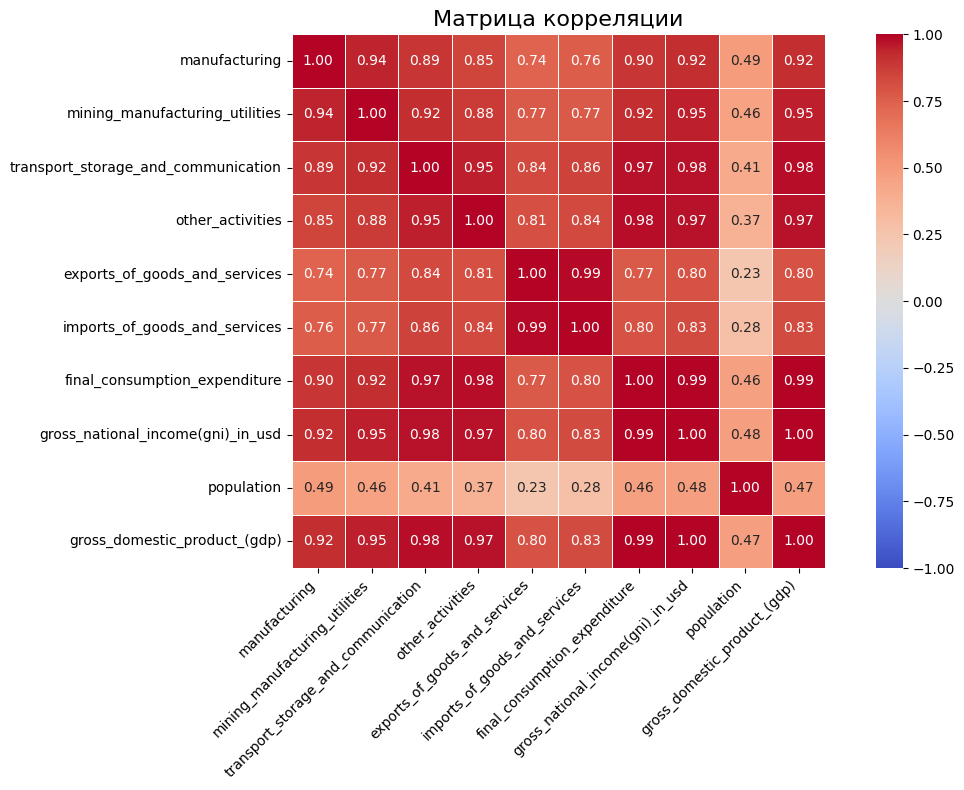

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df= pd.read_csv('/content/drive/MyDrive/colab đại học/môn ML/Tvor/Global-Economy-Indicators.csv')

#1 xử lý cột
standard_columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(',','')
new_columns = dict(zip(df.columns, standard_columns))
df.rename(columns=new_columns, inplace=True)

df.interpolate(inplace=True)
df.info()

#2
original_options = pd.get_option('display.float_format')
pd.set_option('display.float_format', '{:.0f}'.format)
display(df.iloc[:, 3:].describe())
pd.set_option('display.float_format', original_options)
cv = df.iloc[:,3:].std() / df.iloc[:,3:].mean() * 100
print('Коэффицициет вариации:\n')
display(cv)
#3
fig,ax = plt.subplots(2,3, figsize=(15,8))
ax[0,0].hist(df['construction'],bins=50,log=True)
ax[0,1].hist(df['manufacturing'],bins=50,log=True)
ax[0,2].hist(df['mining_manufacturing_utilities'],bins=50,log=True)
ax[1,0].hist(df['transport_storage_and_communication'],bins=50,log=True)
ax[1,1].hist(df['other_activities'],bins=50,log=True)

ax[0,0].set_title('Construction')
ax[0,1].set_title('manufacturing')
ax[0,2].set_title('mining_manufacturing_utilities')
ax[1,0].set_title('transport_storage_and_communication')
ax[1,1].set_title('other_activities')

fig,ax = plt.subplots(2,3, figsize=(15,8))
ax[0,0].hist(df['exports_of_goods_and_services'],bins=50,log=True)
ax[0,1].hist(df['imports_of_goods_and_services'],bins=50,log=True)
ax[0,2].hist(df['final_consumption_expenditure'],bins=50,log=True)
ax[1,0].hist(df['gross_national_income(gni)_in_usd'],bins=50,log=True)
ax[1,1].hist(df['population'],bins=50,log =True)
ax[1,2].hist(df['gross_domestic_product_(gdp)'],bins=50,log=True,color='red')

ax[0,0].set_title('exports')
ax[0,1].set_title('imports')
ax[0,2].set_title('final_consumption_expenditure')
ax[1,0].set_title('gross_national_income')
ax[1,1].set_title('population')
ax[1,2].set_title('GDP')

# 4.	Phân tích mối tương quan giữa các biến số.
cor= df.iloc[:,3:].corr()
# display(round(cor,2))

plt.figure(figsize=(12,8))
sns.heatmap(cor,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1,
            vmax=1)

plt.xticks(rotation=45, ha='right')
plt.title('Матрица корреляции', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-learn
!pip install category_encoders

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

x= df.drop(['gross_domestic_product_(gdp)','country'],axis =1)
y= df['gross_domestic_product_(gdp)']
x_train = x[df['year'] <= 2011]
x_test  = x[df['year'] > 2011]
y_train = y[df['year'] <= 2011]
y_test  = y[df['year'] > 2011]

model =RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)

cv = cross_val_score(model,x_train,y_train,
                     scoring='neg_mean_squared_error',cv= 6)
cv_rmse = np.sqrt(-cv)
print(f"RMSE fold: {cv_rmse}")

y_pred= model.predict(x_test)
print('r2',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('RMSE',root_mean_squared_error(y_test,y_pred))

RMSE fold: [2.29149394e+10 1.61966551e+09 4.96562296e+09 4.97447680e+09
 6.32776959e+09 5.46906288e+09]
r2 0.9930245143583887
MAE 6138545413.711981
MSE 9.177422460590682e+20
RMSE 30294260942.612022


In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

x= df.drop('gross_domestic_product_(gdp)',axis =1)
y= df['gross_domestic_product_(gdp)']
x_train = x[df['year'] <= 2011]
x_test  = x[df['year'] > 2011]
y_train = y[df['year'] <= 2011]
y_test  = y[df['year'] > 2011]

num = x.drop('country',axis=1).columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ('num_features',StandardScaler(),num),
    # year scale cũng không hại gì, ko scale thì có hại nếu model là linear, KNN, SVM, hoặc nếu muốn diễn giải khi dùng linear mỗi năm tăng mấy thì ko cần scaler
    ('country',TargetEncoder(smoothing=10),['country']) # tính mean của y theo category và gán giá trị mean ấy cho tất cả category; hoặc lấy từng GDP trừ mean làm cột đại diện cho nước cx đc (PP của panel data)
    # smoothing vì sợ nếu cate nào có quá ít vd chỉ có 2 dòng về nước pháp thì mean y không tổng quát hóa, smooth giúp tổng quát hóa
])
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor',RandomForestRegressor(random_state=42,'max_depth': [10],'min_samples_split': [5],'min_samples_leaf': [3]))])


model.fit(x_train, y_train)
cv = cross_val_score(model,x_train,y_train,scoring='neg_mean_squared_error',cv= 6)
cv_rmse = np.sqrt(-cv)
print(f"RMSE từng fold: {cv_rmse}")

y_pred= model.predict(x_test)
print('r2',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))
print('RMSE',root_mean_squared_error(y_test,y_pred))

RMSE từng fold: [2.27505044e+10 1.78383127e+09 5.07574497e+09 5.09102918e+09
 6.51900786e+09 5.55661406e+09]
r2 0.9929836412182867
MAE 6119185947.44375
MSE 9.231197938496993e+20
RMSE 30382886529.25688
